In [10]:
import os
import operator
import uuid
from typing import Sequence, Annotated, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from pydantic import SecretStr
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.runnables import RunnableConfig
from langchain.agents import create_agent

# load the env variables from the .env file
load_dotenv()

True

In [ ]:
llm = ChatOpenAI(
            model=os.getenv("MODEL") or "",
            api_key=SecretStr(os.getenv("OPENAI_API_KEY") or ""),
        )

# Defining States

In [ ]:

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    sender: Annotated[str, "The sender of last message"]

## Creating Agents 

### 1. Planning Agent

In [26]:
intent_agent_system_message = """
            You are a construction scheduling assistant. Your goal is to understand what the user wants to build.
            - Ask clarifying questions if the request is vague.
            - Once you understand the project (e.g., "Build a 2-story house"), propose to identify the major construction phases.
            """

from langchain_core.tools import tool

@tool
def transition_to_phases(intent_description: str) -> str:
    """
    Call this tool when the user's intent is clear and you are ready to propose phases.
    This will switch the workflow to the Phase Identification stage.
    """
    return f"Intent confirmed: {intent_description}. Moving to Phase Identification."

intent_agent = create_agent(
    system_prompt=intent_agent_system_message,
    tools=[transition_to_phases],
    model=llm,
)

def intent_node(state: MessagesState) -> MessagesState:
    result = intent_agent.invoke(state)
    last_message = HumanMessage(content=result.content, name="intent")
    return {
        "messages": [last_message],
    }

### 2. Phases Agent

In [17]:
phases_agent_system_message = """
    You are a construction scheduling assistant. 
    - List the major phases for the project based on the user's intent.
    - Ensure you include any necessary Pre-Construction phases (e.g., Permits, Site Prep, Design).
    - Ask the user to confirm if these phases look correct.
    """

phases_agent = create_agent(
    system_prompt=phases_agent_system_message,
    tools=[],
    model=llm,
)

# Defining Phases Agent Node
def phases_node(state: MessagesState) -> MessagesState:
    result = phases_agent.invoke(state)
    last_message = HumanMessage(content=result.content, name="phases")
    return {
        "messages": [last_message],
    }

### Router

In [27]:
# Defining Router
def router(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return "continue"

# Building a multi-agent network workflow
workflow = StateGraph(MessagesState)
workflow.add_node("intent_agent", intent_node)
workflow.add_node("phases_agent", phases_node)

workflow.add_conditional_edges(
    "intent_agent",
    router,
    {"continue": "phases_agent", END: END},
)
workflow.add_conditional_edges(
    "phases_agent",
    router,
    {"continue": "intent_agent", END: END},
)

workflow.add_edge(START, "intent_agent")
app = workflow.compile(checkpointer=MemorySaver())

In [21]:
%%capture --no-stderr
%pip install langchain-opentutorial==0.0.4

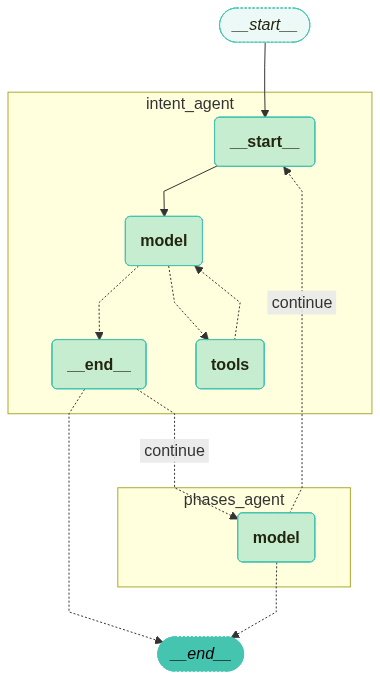

In [28]:
from langchain_opentutorial.graphs import visualize_graph

visualize_graph(app, xray=True)

In [31]:
def intent_node(state: MessagesState) -> MessagesState:
    result = intent_agent.invoke(state)
    
    # Debug: check what the agent returns
    print(f"🔍 Result type: {type(result)}")
    if isinstance(result, dict):
        print(f"🔍 Result keys: {result.keys()}")
    
    # Extract content from the agent response
    if isinstance(result, dict) and "messages" in result:
        # Get the last AI message from the messages list
        messages = result["messages"]
        if messages and hasattr(messages[-1], 'content'):
            content = messages[-1].content
        else:
            content = str(messages)
    elif hasattr(result, 'content'):
        # If it's directly a message object
        content = result.content
    else:
        # Fallback
        content = str(result)
    
    print(f"📝 Extracted content: {content}")
    
    last_message = HumanMessage(content=content, name="intent")
    return {
        "messages": [last_message],
    }

In [32]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage
import uuid

def random_uuid():
    return str(uuid.uuid4())

def invoke_graph(app, inputs, config, node_names=None):
    if node_names:
        return app.invoke(inputs, config, include=node_names)
    else:
        return app.invoke(inputs, config)

# Set up config
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": random_uuid()})

# Input query
inputs = {
    "messages": [
        HumanMessage(content="Schedule a 2-story house.")
    ],
}

# Invoke graph
result = invoke_graph(app, inputs, config, node_names=["intent_agent", "phases_agent"])
print("✅ Final result:", result)

AttributeError: 'dict' object has no attribute 'content'